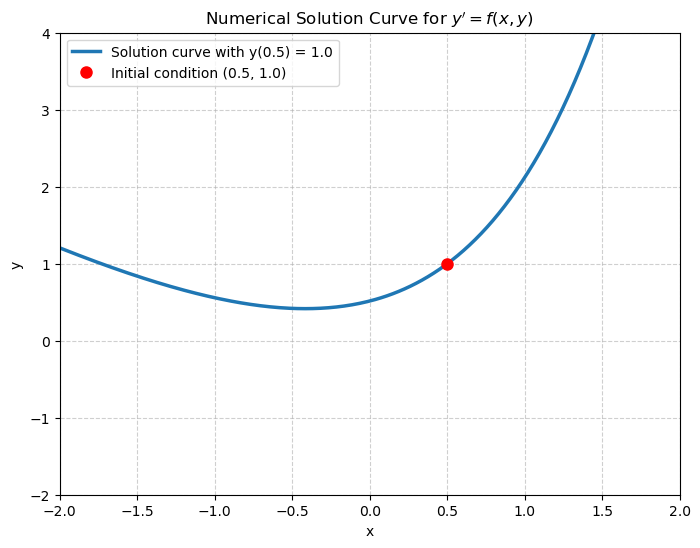

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# ⚙️ GLOBAL PARAMETERS (Define Once)
# ==========================================
def f(x, y):
    return x+y  # Define the ODE: y' = f(x, y)

x_range = (-2.0, 2.0)
y_range = (-2.0, 4.0)
# ==========================================

# Initial condition in the positive quadrant
x0, y0 = 0.5, 1.0

# Generate integration grids forward and backward from x0
eval_fwd = np.linspace(x0, x_range[1], 200)
eval_bwd = np.linspace(x0, x_range[0], 200)

# Integrate forward and backward starting explicitly at x0
sol_fwd = solve_ivp(f, (x0, x_range[1]), [y0], t_eval=eval_fwd)
sol_bwd = solve_ivp(f, (x0, x_range[0]), [y0], t_eval=eval_bwd)

# Combine solutions smoothly (drop duplicate x0 point)
x_sol = np.concatenate((sol_bwd.t[::-1], sol_fwd.t[1:]))
y_sol = np.concatenate((sol_bwd.y[0][::-1], sol_fwd.y[0][1:]))

# Plot single solution
plt.figure(figsize=(8, 6))
plt.plot(x_sol, y_sol, color="tab:blue", linewidth=2.5, label=f"Solution curve with y({x0}) = {y0}")
plt.plot(x0, y0, "ro", markersize=8, label=f"Initial condition ({x0}, {y0})", zorder=5)

# Lock plot to the global limits
plt.xlim(x_range)
plt.ylim(y_range)

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Numerical Solution Curve for $y' = f(x, y)$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

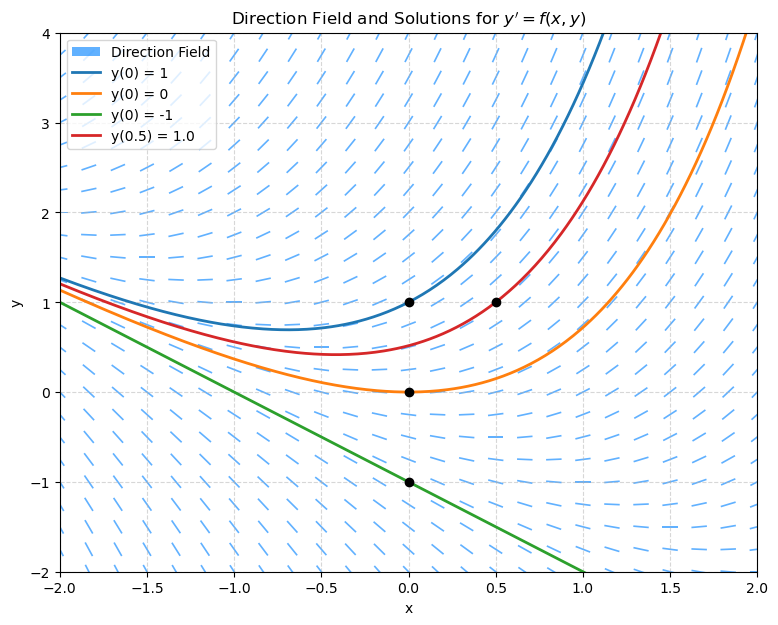

In [26]:
# Inherits f, x_range, and y_range from Cell 1

grid_density = 25
initial_conditions = [(0, 1), (0, 0), (0, -1), (0.5, 1.0)]

# Create grid for direction field
x_vals = np.linspace(x_range[0], x_range[1], grid_density)
y_vals = np.linspace(y_range[0], y_range[1], grid_density)
X, Y = np.meshgrid(x_vals, y_vals)

# Compute slopes dy/dx
slopes = f(X, Y)
dx = np.ones_like(slopes)
dy = slopes

# Normalize vector lengths for uniform visualization
magnitude = np.hypot(dx, dy)
dx_norm = dx / magnitude
dy_norm = dy / magnitude

plt.figure(figsize=(9, 7))

# Draw direction field
plt.quiver(
    X, Y, dx_norm, dy_norm,
    angles="xy",
    pivot="middle",
    headwidth=0,
    headlength=0,
    headaxislength=0,
    color="dodgerblue",
    alpha=0.7,
    label="Direction Field"
)

# Plot solution curves for given initial conditions
for x_start, y_start in initial_conditions:
    eval_fwd = np.linspace(x_start, x_range[1], 200)
    eval_bwd = np.linspace(x_start, x_range[0], 200)
    
    sol_fwd = solve_ivp(f, (x_start, x_range[1]), [y_start], t_eval=eval_fwd)
    sol_bwd = solve_ivp(f, (x_start, x_range[0]), [y_start], t_eval=eval_bwd)
    
    x_sol = np.concatenate((sol_bwd.t[::-1], sol_fwd.t[1:]))
    y_sol = np.concatenate((sol_bwd.y[0][::-1], sol_fwd.y[0][1:]))
    
    plt.plot(x_sol, y_sol, linewidth=2, label=f"y({x_start}) = {y_start}")
    plt.plot(x_start, y_start, "ko", markersize=6, zorder=5)

plt.xlim(x_range)
plt.ylim(y_range)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Direction Field and Solutions for $y' = f(x, y)$")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.show()